## Import Libraries

In [ ]:
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
%matplotlib inline
import json

import warnings
warnings.filterwarnings("ignore")

## Importing the dataset

In [2]:
df = pd.read_csv("../../dataSet/marketing_and_sales_clean.csv")

## Splitting the dataset into the Training set and Test set

In [3]:
X = df[["TV", "Radio", "Influencer", "Social Media"]].values
y = df["Sales"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

On entraine le model sur 2/3 des données, le 3e servira au test

## Training

In [4]:
param_grid = {
    'n_estimators': [500, 800, 1100],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5],
}

reg = GridSearchCV(
    GradientBoostingRegressor(loss='squared_error'),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
reg.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [2, 3, 4], 'min_samples_split': [2, 5],
                         'n_estimators': [500, 800, 1100]},
             scoring='neg_mean_squared_error')

Ici param_grid contient une liste de possibilité pour chacune des 4 variables à haute importance de notre modèle. <br/>
Ce dictionnaire servira à "GridSearchCV" qui fera des combinaisons en se basant sur les différents paramètres et nous renverra le paramètrage du model le plus efficient. <br/>
En l'occurence :
- 'max_depth': 2, 
- 'learning_rate': 0.01, 
- 'min_samples_split': 2, 
- 'n_estimators': 800

In [5]:
print('Meilleurs paramètres: \n', reg.best_params_)
best_rf = reg.best_estimator_

Meilleurs paramètres: 
 {'learning_rate': 0.01, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 800}


In [ ]:
print('Coefficients: \n', best_rf.feature_importances_)

## Prédiction

Text(0, 0.5, 'Predicted Y')

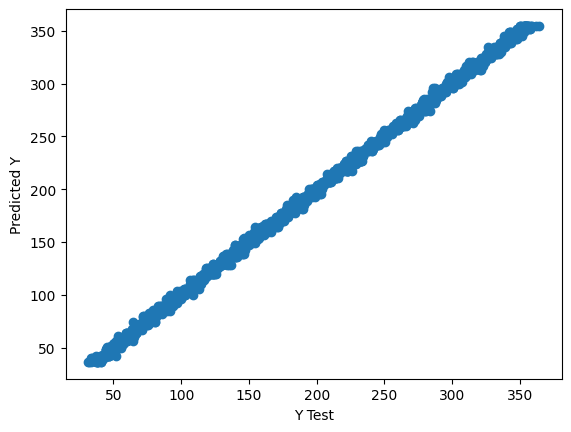

In [ ]:
predictions = best_rf.predict(X_test)
plt.scatter(y_test,predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

## Regression Evaluation Metrics

In [ ]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = metrics.root_mean_squared_error(y_test, predictions)
R2 = metrics.r2_score(y_test, predictions)
print(f"MAE : {MAE}\nMSE : {MSE}\nRMSE : {RMSE}\nR2 : {R2}\n")
with open('../saved_models/gradient_boosting/metrics.json', 'w') as f:
    f.write(json.dump({MAE, MSE, RMSE, R2}))

MAE : 2.4286204475784006
MSE : 9.333005458275311
RMSE : 3.054996801680046
R2 : 0.9989384734943195



## Export model

In [ ]:
import pickle

with open('../saved_models/gradient_boosting/model.pkl', 'wb') as f:
    pickle.dump(reg.best_estimator_, f)